# **역전파 (Backpropagation)**

**인공신경망에서 핵심적으로 구현되는 학습과정 중 하나**

**학습과정의 정확히 역방향으로 가중치를 계산하여 은닉층의 가중치를 수정하는 과정**

## **코드 구조**
- 입력층 2개
- 은닉층 3개
- 출력층 1개

## **활성화 함수**
- Sigmoid 함수

## **손실 함수**
- MSE

## **Optimizer**
- SGD

In [10]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
X = torch.tensor([ # xor 문제의 입력값
    [0., 0.],
    [0., 1.],
    [1., 0.],
    [1., 1.]
])

y = torch.tensor([ # xor 문제의 출력값
    [0.],
    [1.],
    [1.],
    [0.],
])

In [ ]:
model = nn.Sequential( ## 순서대로 층을 쌓겠다는 뜻
    nn.Linear(2,3), # 입력층 2개, 은닉층 3개
    nn.Sigmoid(), # 활성화 함수
    nn.Linear(3,1), # 은닉층 3개, 출력층 1개
    nn.Sigmoid() # 최종 출력값 = 0에서 1 사이 -> 확률값
)

In [ ]:
loss_fn = nn.MSELoss() # MSE (평균 제곱 오차)

In [ ]:
# optimizer? 
# 손실을 줄이기 위해 모델의 가중치를 실제로 어떻게 수정할지 결정하는 알고리즘

optimizer = torch.optim.SGD(model.parameters(), lr = 0.5) # SGD (확률적 경사 하강법)

In [19]:
grad_history = [] # 매 Epoch마다 계산된 가중치의 Gradient(기울기) 값들을 순차적으로 저장하기 위해 만든 빈 리스트

In [ ]:
for epochs in range(1000):
    pred = model(X)
    loss = loss_fn(pred, y)
    optimizer.zero_grad() # 기울기 초기화
    loss.backward() # 기울기 계산

    grads = []
    for param in model.parameters():
        grads.append(param.grad.abs().mean().item())

    grad_history.append(grads)
    if epochs % 100 == 0:
        print("epoch:", epochs)
        print("loss:", loss.item())
        print("prediction:")
        print(pred.detach())
        print("gradient:", grads)
        print()
    optimizer.step() # 가중치 업데이트

epoch: 0
loss: 0.27924996614456177
prediction:
tensor([[0.3251],
        [0.3338],
        [0.3242],
        [0.3328]])
gradient: [0.002026537200435996, 0.004013544879853725, 0.034680549055337906, 0.07549308240413666]

epoch: 100
loss: 0.2498953640460968
prediction:
tensor([[0.5047],
        [0.5042],
        [0.4963],
        [0.4953]])
gradient: [0.00016119198699016124, 0.00010315777035430074, 0.0001907111145555973, 6.418675184249878e-05]

epoch: 200
loss: 0.2498706579208374
prediction:
tensor([[0.5046],
        [0.5038],
        [0.4968],
        [0.4954]])
gradient: [0.00016847446386236697, 0.0001095615079975687, 0.0002071097696898505, 7.11195170879364e-05]

epoch: 300
loss: 0.2498416155576706
prediction:
tensor([[0.5046],
        [0.5034],
        [0.4972],
        [0.4954]])
gradient: [0.00018256111070513725, 0.00012053576210746542, 0.00022776261903345585, 7.664784789085388e-05]

epoch: 400
loss: 0.2498060166835785
prediction:
tensor([[0.5044],
        [0.5031],
        [0.4977],

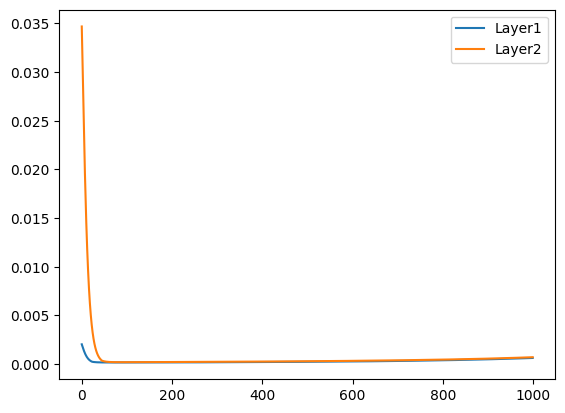

In [ ]:
grad_history = np.array(grad_history)

plt.plot(grad_history[:,0], label = 'Layer1') # 첫 번째 Linear 층 가중치 index 0 편향 index 1
plt.plot(grad_history[:,2], label = 'Layer2') # 두 번째 Linear 층 가중치 index 2 편향 index 3
plt.legend()
plt.show()

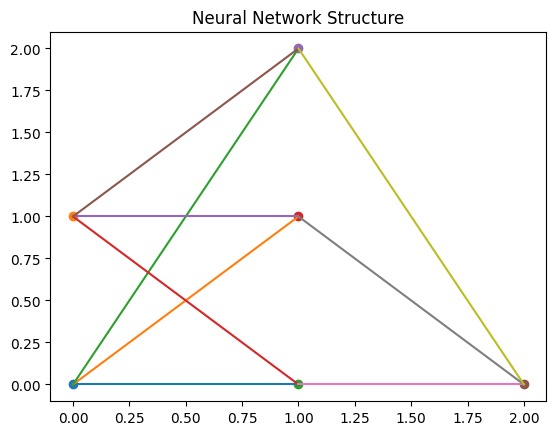

In [ ]:
layers = [2, 3, 1] # 입력층(2), 은닉층(3), 출력층(1)의 노드 개수를 리스트로 정의

for i, layer in enumerate(layers) : # 각 층(i)을 순회하며 층 내부의 정의된 layer 만큼 노드 시각화
    for k in range(layer) :
        plt.scatter(i, k) # x축은 층의 위치(i), y축은 노드의 순서(k)로 점을 찍음

for i in range (len(layers)-1) : # 인접한 두 층(i, i+1) 사이의 모든 연결선을 그리는 과정
    for j in range (layers[i]) : # 현재 층 노드
        for k in range (layers[i+1]) : # 다음 층 노드
            plt.plot([i, i+1], [j, k]) # 두 노드 사이를 잇는 직선 -> 연결관계 표현

plt.title('Neural Network Structure')
plt.show()